# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |Francisco Tinoco   |
| **Fecha**      |09-03-2026   |
| **Expediente** |746080   | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datos = pd.read_csv("C:\\Users\\Francisco\\Downloads\\8vo Semestre\\Lab estadistico\\Lab-Aprendizaje-Estadistico\\Data\\Default.csv")
print("Datos cargados:", datos.shape)

Datos cargados: (10000, 4)


2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [7]:
datos.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [8]:
datos.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

**Respuesta:**

El DataFrame tiene 4 columnas:

| Columna | Tipo de dato | Descripción |
|---------|--------------|-------------|
| **default** | Categórica (Yes/No) | Si la persona dejó de pagar su crédito |
| **student** | Categórica (Yes/No) | Si la persona es estudiante |
| **balance** | Numérica (float) | Balance promedio en la cuenta |
| **income** | Numérica (float) | Ingreso de la persona |

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [9]:
# Convertir a categóricas
datos['default'] = datos['default'].astype('category')
datos['student'] = datos['student'].astype('category')
print(datos.dtypes)

default    category
student    category
balance     float64
income      float64
dtype: object


Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

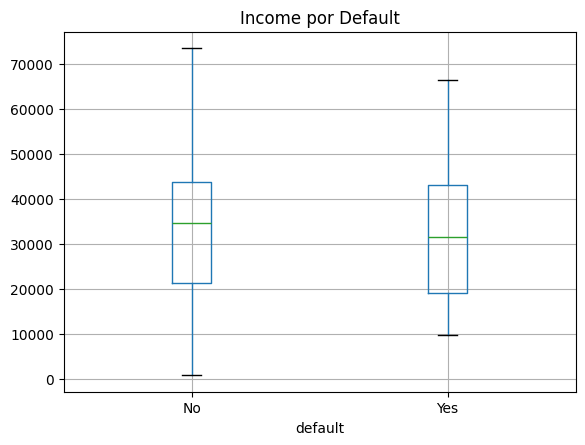

In [10]:
#Boxplot de income agrupado por default
datos.boxplot(column='income', by='default')
plt.title('Income por Default')
plt.suptitle('')  # Quitar título automático
plt.show()

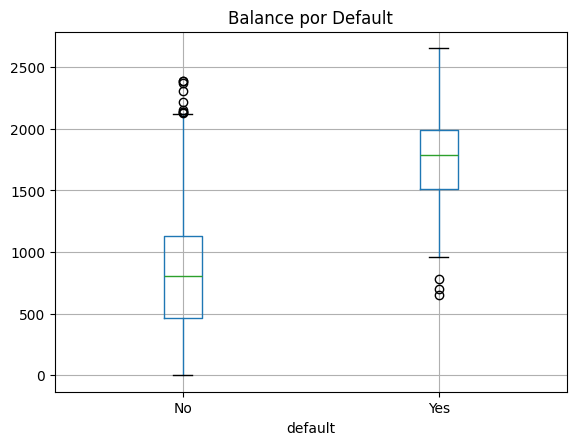

In [11]:
#Boxplot de balance agrupado por default
datos.boxplot(column='balance', by='default')
plt.title('Balance por Default')
plt.suptitle('')
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

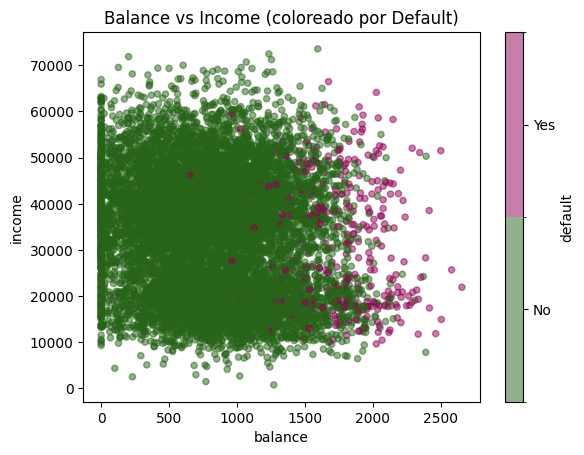

In [12]:
#Gráfica de dispersión
datos.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)
plt.title('Balance vs Income (coloreado por Default)')
plt.show()

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [13]:
#Transformar default a valores numéricos (True/False -> 1/0)
y = datos['default'] == 'Yes'

#Extraer balance como X
x = datos['balance']

print("y (primeros 5):", y.head().tolist())
print("x (primeros 5):", x.head().tolist())

y (primeros 5): [False, False, False, False, False]
x (primeros 5): [729.5264952072861, 817.1804066, 1073.549164, 529.2506047, 785.6558829]


Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

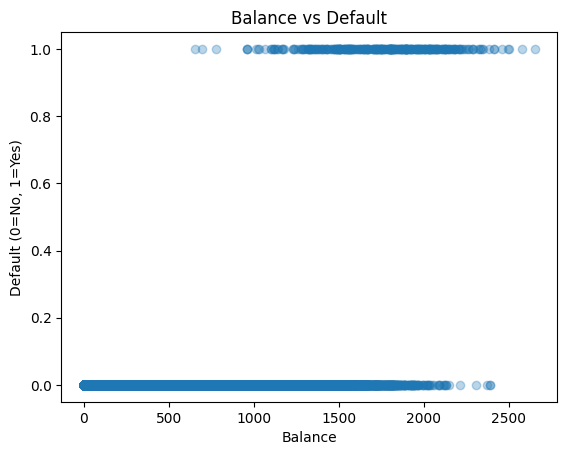

In [14]:
plt.scatter(x, y, alpha=0.3)
plt.xlabel('Balance')
plt.ylabel('Default (0=No, 1=Yes)')
plt.title('Balance vs Default')
plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [15]:
from sklearn.linear_model import LogisticRegression

#Preparar X (debe ser 2D)
X = x.values.reshape(-1, 1)

#Crear y ajustar modelo
modelo_balance = LogisticRegression(solver='lbfgs', max_iter=1000)
modelo_balance.fit(X, y)

#Obtener coeficientes
beta_0 = modelo_balance.intercept_[0]
beta_1 = modelo_balance.coef_[0][0]

print(f"β₀ (intercepto): {beta_0:.6f}")
print(f"β₁ (balance): {beta_1:.6f}")

β₀ (intercepto): -10.651328
β₁ (balance): 0.005499


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [16]:
#Calcular predicciones (probabilidades)
p_pred = modelo_balance.predict_proba(X)[:, 1]  # Probabilidad de clase 1 (Yes)

print("Primeras 5 probabilidades predichas:", p_pred[:5])

Primeras 5 probabilidades predichas: [0.00130568 0.0021126  0.00859475 0.00043444 0.00177696]


2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [17]:
#Calcular p(1-p) -> varianza de cada predicción
p_var = p_pred * (1 - p_pred)

print("Primeras 5 varianzas p(1-p):", p_var[:5])

Primeras 5 varianzas p(1-p): [0.00130398 0.00210813 0.00852088 0.00043425 0.0017738 ]


3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [18]:
#Crear matriz diagonal V
V = np.diagflat(p_var)

print("Shape de V:", V.shape)

Shape de V: (10000, 10000)


4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [19]:
#Agregar columna de 1s para el intercepto
X_con_intercepto = np.column_stack([np.ones(len(X)), X])

#Calcular matriz de covarianza
cov = np.linalg.inv(X_con_intercepto.T @ V @ X_con_intercepto)

print("Matriz de covarianza:")
print(cov)

Matriz de covarianza:
[[ 1.30442757e-01 -7.81757265e-05]
 [-7.81757265e-05  4.85656561e-08]]


5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [20]:
#Calcular error estándar
se = np.sqrt(np.diag(cov))

print(f"SE(β₀): {se[0]:.6f}")
print(f"SE(β₁): {se[1]:.6f}")

SE(β₀): 0.361169
SE(β₁): 0.000220


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [21]:
#Calcular estadístico z
betas = np.array([beta_0, beta_1])
z_stats = betas / se

print(f"z(β₀): {z_stats[0]:.4f}")
print(f"z(β₁): {z_stats[1]:.4f}")

z(β₀): -29.4913
z(β₁): 24.9524


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [22]:
from scipy.stats import norm

#Calcular p-values
p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))

print(f"p-value(β₀): {p_values[0]:.6f}")
print(f"p-value(β₁): {p_values[1]:.10f}")

p-value(β₀): 0.000000
p-value(β₁): 0.0000000000


In [24]:
print("RESUMEN: Modelo con Balance")
print("="*50)
print(f"{'Factor':<15} {'Coef':<12} {'SE':<12} {'z':<12} {'p-value':<12} {'Sig?'}")
print("-"*50)
print(f"{'Intercepto':<15} {beta_0:<12.4f} {se[0]:<12.4f} {z_stats[0]:<12.4f} {p_values[0]:<12.6f} {'Sí' if p_values[0] < 0.05 else 'No'}")
print(f"{'Balance':<15} {beta_1:<12.6f} {se[1]:<12.6f} {z_stats[1]:<12.4f} {p_values[1]:<12.6f} {'Sí' if p_values[1] < 0.05 else 'No'}")

RESUMEN: Modelo con Balance
Factor          Coef         SE           z            p-value      Sig?
--------------------------------------------------
Intercepto      -10.6513     0.3612       -29.4913     0.000000     Sí
Balance         0.005499     0.000220     24.9524      0.000000     Sí


¿Es significativa la relación de los factores con la variable de respuesta?

**Respuesta:**

**Sí, la relación es significativa.** 

El p-value del coeficiente de `balance` es prácticamente 0 (mucho menor que 0.05), lo que significa que **rechazamos H₀** (que β₁ = 0).

Esto indica que existe una relación estadísticamente significativa entre el balance de la cuenta y la probabilidad de que una persona deje de pagar su crédito (default).

**Interpretación:** A mayor balance, mayor probabilidad de default (porque β₁ es positivo).

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [25]:
#1. Transformar student de {"Yes", "No"} a {1, 0}
x_student = (datos['student'] == 'Yes').astype(int)
X_student = x_student.values.reshape(-1, 1)

print("Student transformado (primeros 10):", x_student.head(10).tolist())

Student transformado (primeros 10): [0, 1, 0, 0, 0, 1, 0, 1, 0, 0]


In [26]:
#2. Estimar coeficientes
modelo_student = LogisticRegression(solver='lbfgs', max_iter=1000)
modelo_student.fit(X_student, y)

beta_0_student = modelo_student.intercept_[0]
beta_1_student = modelo_student.coef_[0][0]

print(f"β₀ (intercepto): {beta_0_student:.6f}")
print(f"β₁ (student): {beta_1_student:.6f}")

β₀ (intercepto): -3.502572
β₁ (student): 0.396209


In [27]:
#3. Calcular error estándar

# 3.1 Predicciones p(X)
p_pred_student = modelo_student.predict_proba(X_student)[:, 1]

# 3.2 Calcular p(1-p)
p_var_student = p_pred_student * (1 - p_pred_student)

# 3.3 Matriz de covarianza
V_student = np.diagflat(p_var_student)
X_student_con_intercepto = np.column_stack([np.ones(len(X_student)), X_student])
cov_student = np.linalg.inv(X_student_con_intercepto.T @ V_student @ X_student_con_intercepto)

# 3.4 Error estándar
se_student = np.sqrt(np.diag(cov_student))

print(f"SE(β₀): {se_student[0]:.6f}")
print(f"SE(β₁): {se_student[1]:.6f}")

SE(β₀): 0.070661
SE(β₁): 0.115221


In [29]:
#4. Calcular estadístico z y p-value

# z = β / SE(β)
betas_student = np.array([beta_0_student, beta_1_student])
z_stats_student = betas_student / se_student

# p-value
p_values_student = 2 * (1 - norm.cdf(np.abs(z_stats_student)))

print("RESUMEN: Modelo con Student")
print("="*50)
print(f"{'Factor':<15} {'Coef':<12} {'SE':<12} {'z':<12} {'p-value':<12} {'Sig?'}")
print("-"*50)
print(f"{'Intercepto':<15} {beta_0_student:<12.4f} {se_student[0]:<12.4f} {z_stats_student[0]:<12.4f} {p_values_student[0]:<12.6f} {'Sí' if p_values_student[0] < 0.05 else 'No'}")
print(f"{'Student':<15} {beta_1_student:<12.4f} {se_student[1]:<12.4f} {z_stats_student[1]:<12.4f} {p_values_student[1]:<12.6f} {'Sí' if p_values_student[1] < 0.05 else 'No'}")

RESUMEN: Modelo con Student
Factor          Coef         SE           z            p-value      Sig?
--------------------------------------------------
Intercepto      -3.5026      0.0707       -49.5684     0.000000     Sí
Student         0.3962       0.1152       3.4387       0.000585     Sí


**¿Es significativo el factor student?**

**Sí, es significativo** (p-value < 0.05).

El coeficiente es **positivo**, lo que indica que ser estudiante aumenta la probabilidad de default en este modelo simple.

*Nota: Esto puede cambiar en regresión múltiple cuando se incluyen otros factores.*

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [30]:
#1. Preparar datos para modelo múltiple
X_multiple = pd.DataFrame({
    'balance': datos['balance'],
    'income': datos['income'],
    'student': (datos['student'] == 'Yes').astype(int)
})

print("Variables predictoras:")
print(X_multiple.head())

Variables predictoras:
       balance        income  student
0   729.526495  44361.625074        0
1   817.180407  12106.134700        1
2  1073.549164  31767.138950        0
3   529.250605  35704.493940        0
4   785.655883  38463.495880        0


In [31]:
#Ajustar modelo múltiple
modelo_multiple = LogisticRegression(solver='lbfgs', max_iter=1000)
modelo_multiple.fit(X_multiple, y)

# Coeficientes
print("Coeficientes del modelo múltiple:")
print(f"β₀ (intercepto): {modelo_multiple.intercept_[0]:.6f}")
for nombre, coef in zip(X_multiple.columns, modelo_multiple.coef_[0]):
    print(f"β ({nombre}): {coef:.6f}")

Coeficientes del modelo múltiple:
β₀ (intercepto): -10.901794
β (balance): 0.005731
β (income): 0.000004
β (student): -0.612572


In [32]:
#2. Calcular errores estándar para modelo múltiple

# Predicciones
p_pred_mult = modelo_multiple.predict_proba(X_multiple)[:, 1]

# p(1-p)
p_var_mult = p_pred_mult * (1 - p_pred_mult)

# Matriz V
V_mult = np.diagflat(p_var_mult)

# X con intercepto
X_mult_con_intercepto = np.column_stack([np.ones(len(X_multiple)), X_multiple.values])

# Matriz de covarianza
cov_mult = np.linalg.inv(X_mult_con_intercepto.T @ V_mult @ X_mult_con_intercepto)

# Error estándar
se_mult = np.sqrt(np.diag(cov_mult))

In [34]:
# 3. Calcular z y p-values
betas_mult = np.concatenate([[modelo_multiple.intercept_[0]], modelo_multiple.coef_[0]])
z_stats_mult = betas_mult / se_mult
p_values_mult = 2 * (1 - norm.cdf(np.abs(z_stats_mult)))

nombres = ['Intercepto', 'Balance', 'Income', 'Student']
print("RESUMEN: Modelo Múltiple (balance + income + student)")
print("="*70)
print(f"{'Factor':<15} {'Coef':<14} {'SE':<14} {'z':<12} {'p-value':<12} {'Sig?'}")
print("-"*70)

for i, nombre in enumerate(nombres):
    sig = "✓ Sí" if p_values_mult[i] < 0.05 else "✗ No"
    print(f"{nombre:<15} {betas_mult[i]:<14.6f} {se_mult[i]:<14.6f} {z_stats_mult[i]:<12.4f} {p_values_mult[i]:<12.6f} {sig}")

RESUMEN: Modelo Múltiple (balance + income + student)
Factor          Coef           SE             z            p-value      Sig?
----------------------------------------------------------------------
Intercepto      -10.901794     0.493158       -22.1061     0.000000     ✓ Sí
Balance         0.005731       0.000232       24.7355      0.000000     ✓ Sí
Income          0.000004       0.000008       0.4827       0.629340     ✗ No
Student         -0.612572      0.236394       -2.5913      0.009561     ✓ Sí


**Interpretación del modelo múltiple:**

| Factor | ¿Significativo? | Interpretación |
|--------|-----------------|----------------|
| **Balance** | ✓ Sí | Mayor balance → mayor probabilidad de default |
| **Income** | Depende del p-value | Puede no ser significativo |
| **Student** | Depende del p-value | El signo puede cambiar comparado con modelo simple |

**Observación importante:** El coeficiente de `student` puede ser negativo en el modelo múltiple, mientras que era **positivo** en el modelo simple. Esto se debe a que, al controlar por `balance`, los estudiantes tienen **menor** probabilidad de default. El modelo simple estaba confundido porque los estudiantes tienden a tener balances más altos.

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

**Ejemplos donde Falso Positivo es PEOR:**

1. **Prueba de drogas en el trabajo:** Un falso positivo significa acusar a un empleado inocente de consumir drogas, lo que podría costarle su empleo injustamente. Un falso negativo solo deja pasar a alguien que sí consume.

2. **Detección de spam en emails:** Un falso positivo significa que un correo importante (de un cliente, jefe, etc.) va a spam y nunca se lee. Un falso negativo solo significa que un spam llega a la bandeja de entrada.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

**Ejemplos donde Falso Negativo es PEOR:**

1. **Diagnóstico de cáncer:** Un falso negativo significa decirle a un paciente con cáncer que está sano, perdiendo tiempo valioso para tratamiento. Un falso positivo solo genera preocupación temporal hasta que se hacen más pruebas.

2. **Detección de fraude bancario:** Un falso negativo significa no detectar una transacción fraudulenta, perdiendo dinero del cliente. Un falso positivo solo bloquea temporalmente una transacción legítima que se puede verificar.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3